In [1]:
import cooler
import cooltools
import bioframe as bf
import bbi
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ggner_3d.cm import CLR_CONNS, get_expected_cis_df, prepare_view_df
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score, get_insulation_fixed
from ggner_3d.dots_common import compare_loops_with_strength
from ggner_3d.bbi_helpers import stackup_bw_dict, stackup_bw_dict_q


NPROC = 8
resolution = 10000
window = 500_000
clr_ = CLR_CONNS(resolution)

# tad lengths
MAXLEN = 2e6
MINLEN = 2.5e5

rescale_flank = 2
rescale_size = 33 * (2 * rescale_flank + 1)
assert rescale_size % (2 * rescale_flank + 1) == 0 and rescale_size % 2 == 1, "rescale_size"
score_flank=rescale_flank

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
from ggner_3d import plotting
from ggner_3d.plotting import plot_flanks_start_end_stackup, lineplot_stackup_dict
plotting.update_rcparams()

In [ ]:
# data paths

# CTCF

ctcf_wt_dict = {
'wt_nouv_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP2.mLb.clN.rpgc.bw'
],
'wt_3h_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_3h_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_3h_REP2.mLb.clN.rpgc.bw'
],
'xpcko_nouv_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_NoUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_NoUV_REP2.mLb.clN.rpgc.bw'
],
'xpcko_3h_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_3h_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_3h_REP2.mLb.clN.rpgc.bw'
]
}

# Damage-seq

ds_dict_obs = {
    'wt_nouv_ds': ['/home/carlos/oldies/ner_collab/damageseq/obs0_rpm.1000bp.bw'],
    'wt_3h_ds': ['/home/carlos/oldies/ner_collab/damageseq/obs3_rpm.1000bp.bw'],
}

ds_dict_exp = {
    'wt_nouv_ds': ['/home/carlos/oldies/ner_collab/damageseq/exp0_rpm.1000bp.bw'],
    'wt_3h_ds': ['/home/carlos/oldies/ner_collab/damageseq/exp3_rpm.1000bp.bw'],
}

# XPC

xpc_wt_dict = {
'wt_nouv_xpc': [
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP3.mLb.clN.rpgc.bw'
],
'wt_1h_xpc': [
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_1h_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_1h_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_1h_REP3.mLb.clN.rpgc.bw'
],
'wt_3h_xpc': [
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_3h_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_3h_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_3h_REP3.mLb.clN.rpgc.bw'
],
}


# ATAC

atac_wt_dict = {
    'wt_nouv_atac': [
        '/home/carlos/Clone/ggner-3d/misc/WT_noUV.mRp.clN.sorted.RPGC.bs10.sl30.mapq30.ATACshift0.bw',
    ],
    'wt_3h_atac': [
        '/home/carlos/Clone/ggner-3d/misc/WT_UV3h.mRp.clN.sorted.RPGC.bs10.sl30.mapq30.ATACshift0.bw',
    ]
}


### TADs prep

In [4]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

insulation_table_ = [
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv'),
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WT3h_10000bp.csv'),
]

comparisons = [(0,1)]
comparisons_str = ['WTnoUV_WT3h']
sample_names_str = ['WTnoUV', 'WT3h']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_table_,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, clr_['WTnoUV'].bins()[:], bin_column='idx1') for df in dfs
]

tads = make_tads(dfs[0][['chrom', 'start', 'end']], maxlen=MAXLEN, minlen=MINLEN).sort_values(['chrom', 'start', 'end']).reset_index(drop=True)

WTnoUV_WT3h: Preserved / Increase ::: 1560
WTnoUV_WT3h: Preserved / Decrease ::: 1002


In [5]:
flank_ratio = 0.25
tads['flank_size'] = (tads['end'] - tads['start']) * flank_ratio
tads['flank_start'] = tads['start'] - tads['flank_size']
tads['flank_end'] = tads['end'] + tads['flank_size']

### Loops prep

In [6]:
dots_wt_nouv = pd.read_csv('/home/carlos/Clone/ggner-3d/data/dots/dots_WTnoUV_10000.csv')
dots_wt_3h = pd.read_csv('/home/carlos/Clone/ggner-3d/data/dots/dots_WT3h_10000.csv')

In [7]:

expected_wtnouv = get_expected_cis_df('WTnoUV', resolution_kb=resolution//1000, label='arm')
expected_wt3h = get_expected_cis_df('WT3h', resolution_kb=resolution//1000, label='arm')

view_df = prepare_view_df(arm=True)

loops_dict = compare_loops_with_strength(
    df_a=dots_wt_nouv,
    df_b=dots_wt_3h,
    clr_a=clr_['WTnoUV'],
    clr_b=clr_['WT3h'],
    expected_a=expected_wtnouv,
    expected_b=expected_wt3h,
    view_df_a=view_df,
    view_df_b=view_df,
    resolution=resolution,
    clustering_radius=20000,
    flank=100000,
    clr_weight_name='sweight',
    nproc=NPROC,
    sample_a_name='WTnoUV',
    sample_b_name='WT3h',
    compute_strength=False,
)

In [11]:
loops_full_common = loops_dict['common_loops'].copy()
loops_full_common['chrom'] = loops_full_common['chrom1_WTnoUV']
loops_full_common['start'] = loops_full_common['start1_WTnoUV']
loops_full_common['end'] = loops_full_common['end2_WTnoUV']
loops_full_common['length'] = loops_full_common['end'] - loops_full_common['start']
loops_full_common['flank_start'] = loops_full_common['start'] - loops_full_common['length'] * flank_ratio
loops_full_common['flank_end'] = loops_full_common['end'] + loops_full_common['length'] * flank_ratio
loops_full_common.shape

(10869, 23)

In [24]:
tads.shape, loops_full_common.shape

((2285, 6), (10869, 23))

### Data viz (scaled TADs and Loops)

In [12]:
# Full stackups - TADs
ctcf_stackup_tads = stackup_bw_dict(ctcf_wt_dict, tads)
ds_stackup_obs_tads = stackup_bw_dict(ds_dict_obs, tads)
xpc_stackup_tads = stackup_bw_dict(xpc_wt_dict, tads)
atac_stackup_tads = stackup_bw_dict(atac_wt_dict, tads)

# Full stackups - Loops
ctcf_stackup_loops = stackup_bw_dict(ctcf_wt_dict, loops_full_common)
ds_stackup_obs_loops = stackup_bw_dict(ds_dict_obs, loops_full_common)
xpc_stackup_loops = stackup_bw_dict(xpc_wt_dict, loops_full_common)
atac_stackup_loops = stackup_bw_dict(atac_wt_dict, loops_full_common)

/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:19: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}


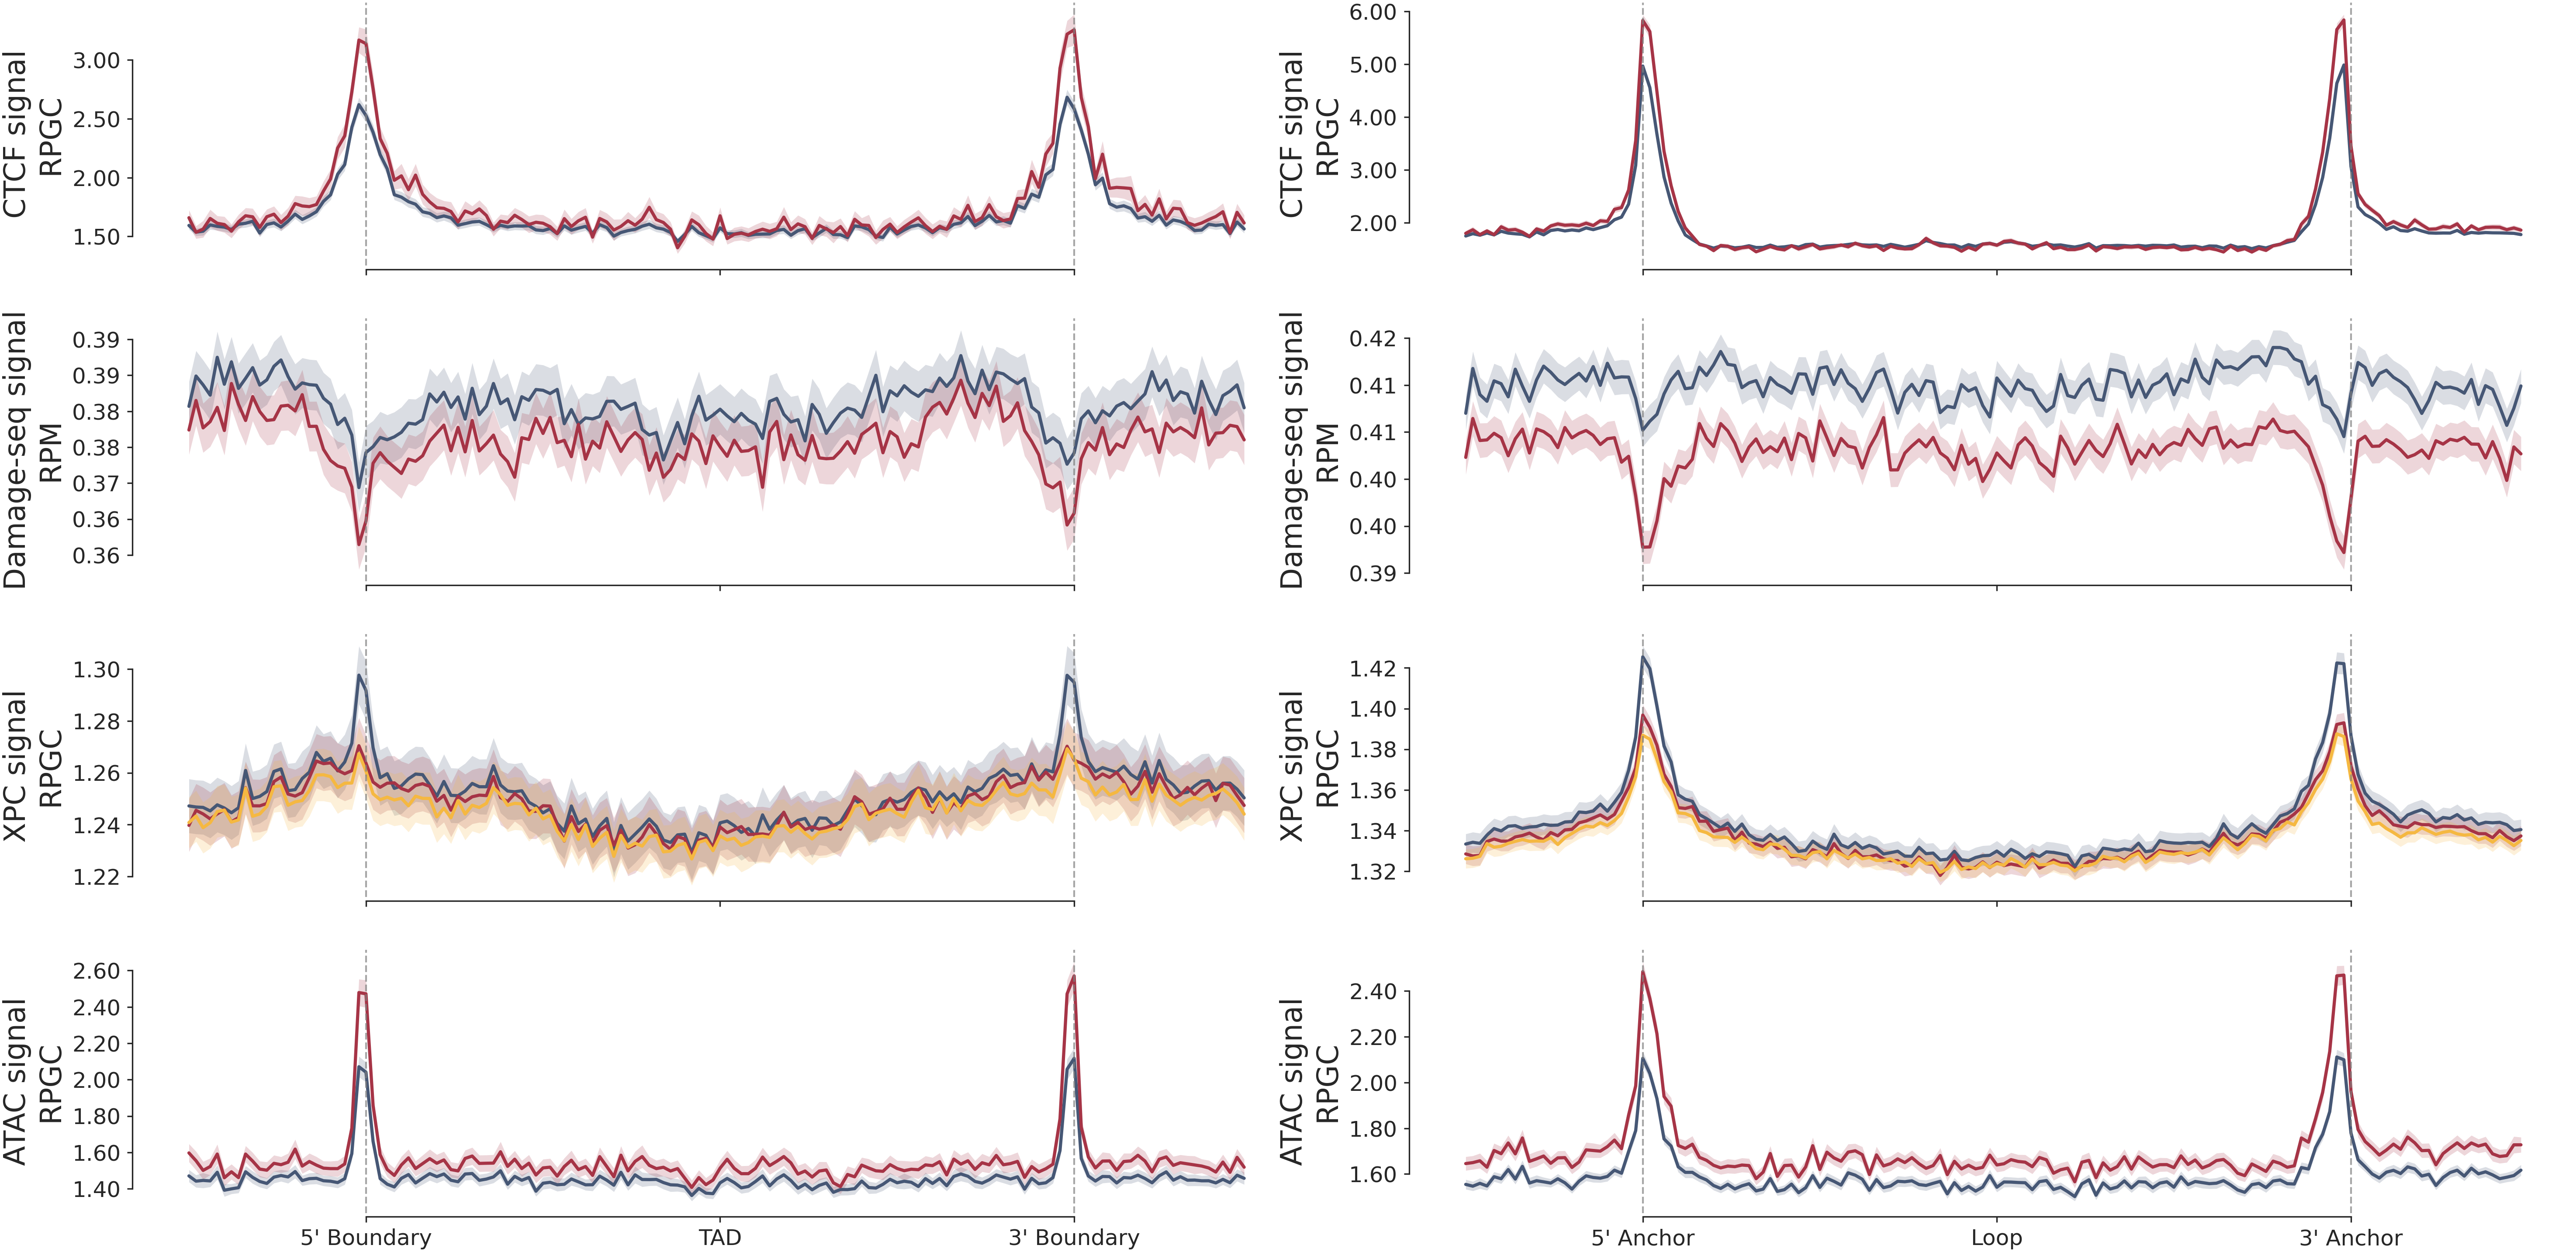

In [13]:
fig, axs = plt.subplots(4, 2, figsize=(24, 12), sharex='col', 
                        gridspec_kw={'wspace': 0.1}
                        )

common_params = {
    'plot_kwargs': {'linewidth': 1.75},
    'colors': plotting.COLORS
}

########
# TADS
########
lineplot_stackup_dict(
    {k: v for k, v in ctcf_stackup_tads.items() if 'wt' in k},
    ax=axs[0, 0],
    labels={
        'wt_nouv_ctcf': 'WT NoUV',
        'wt_3h_ctcf': 'WT 3h',
        # 'xpcko_nouv_ctcf': 'XPCKO NoUV',
        # 'xpcko_3h_ctcf': 'XPCKO 3h'
    },
    legend_title='CTCF ChIP-seq',
    y_title='CTCF signal\nRPGC',
    structure_type='TAD',
    **common_params
)

lineplot_stackup_dict(
    ds_stackup_obs_tads,
    ax=axs[1, 0],
    labels={
        'wt_nouv_ds': 'WT NoUV',
        'wt_3h_ds': 'WT 3h',
    },
    legend_title='Damage-seq',
    y_title='Damage-seq signal\nRPM',
    structure_type='TAD',
    **common_params
)

lineplot_stackup_dict(
    xpc_stackup_tads,
    ax=axs[2, 0],
    labels={
        'wt_nouv_xpc': 'WT NoUV',
        'wt_1h_xpc': 'WT 1h',
        'wt_3h_xpc': 'WT 3h',
    },
    legend_title='XPC ChIP-seq',
    y_title='XPC signal\nRPGC',
    structure_type='TAD',
    **common_params
)

lineplot_stackup_dict(
    atac_stackup_tads,
    ax=axs[3, 0],
    labels={
        'wt_nouv_atac': 'WT NoUV',
        'wt_3h_atac': 'WT 3h',
    },
    legend_title='ATAC-seq',
    y_title='ATAC signal\nRPGC',
    structure_type='TAD',
    **common_params
)

########
# LOOPS
########

lineplot_stackup_dict(
    {k: v for k, v in ctcf_stackup_loops.items() if 'wt' in k},
    ax=axs[0, 1],
    labels={
        'wt_nouv_ctcf': 'WT NoUV',
        'wt_3h_ctcf': 'WT 3h',
        # 'xpcko_nouv_ctcf': 'XPCKO NoUV',
        # 'xpcko_3h_ctcf': 'XPCKO 3h'
    },
    structure_type='Loop',
    legend_title='CTCF ChIP-seq',
    y_title='CTCF signal\nRPGC',
    **common_params
)

lineplot_stackup_dict(
    ds_stackup_obs_loops,
    ax=axs[1, 1],
    labels={
        'wt_nouv_ds': 'WT NoUV',
        'wt_3h_ds': 'WT 3h',
    },
    structure_type='Loop',
    legend_title='Damage-seq',
    y_title='Damage-seq signal\nRPM',
    **common_params
)

lineplot_stackup_dict(
    xpc_stackup_loops,
    ax=axs[2, 1],
    labels={
        'wt_nouv_xpc': 'WT NoUV',
        'wt_1h_xpc': 'WT 1h',
        'wt_3h_xpc': 'WT 3h',
    },
    structure_type='Loop',
    legend_title='XPC ChIP-seq',
    y_title='XPC signal\nRPGC',
    **common_params
)

lineplot_stackup_dict(
    atac_stackup_loops,
    ax=axs[3, 1],
    labels={
        'wt_nouv_atac': 'WT NoUV',
        'wt_3h_atac': 'WT 3h',
    },
    structure_type='Loop',
    legend_title='ATAC-seq',
    y_title='ATAC signal\nRPGC',
    **common_params
)

for ax in axs.flatten():
    plotting.despine(ax=ax)
    # make x, y labels bigger
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    # remove legends
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    # make x and y ticks bigger
    ax.tick_params(axis='both', which='major', labelsize=12)

    # make y ticks 2 digits after comma
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig2_rework2/stackups_tads_loops.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig2_rework2/stackups_tads_loops.svg', dpi=300, bbox_inches='tight')

### 5' and 3' Boundaries and Anchors

TAD nbins: 200, Loop nbins: 100


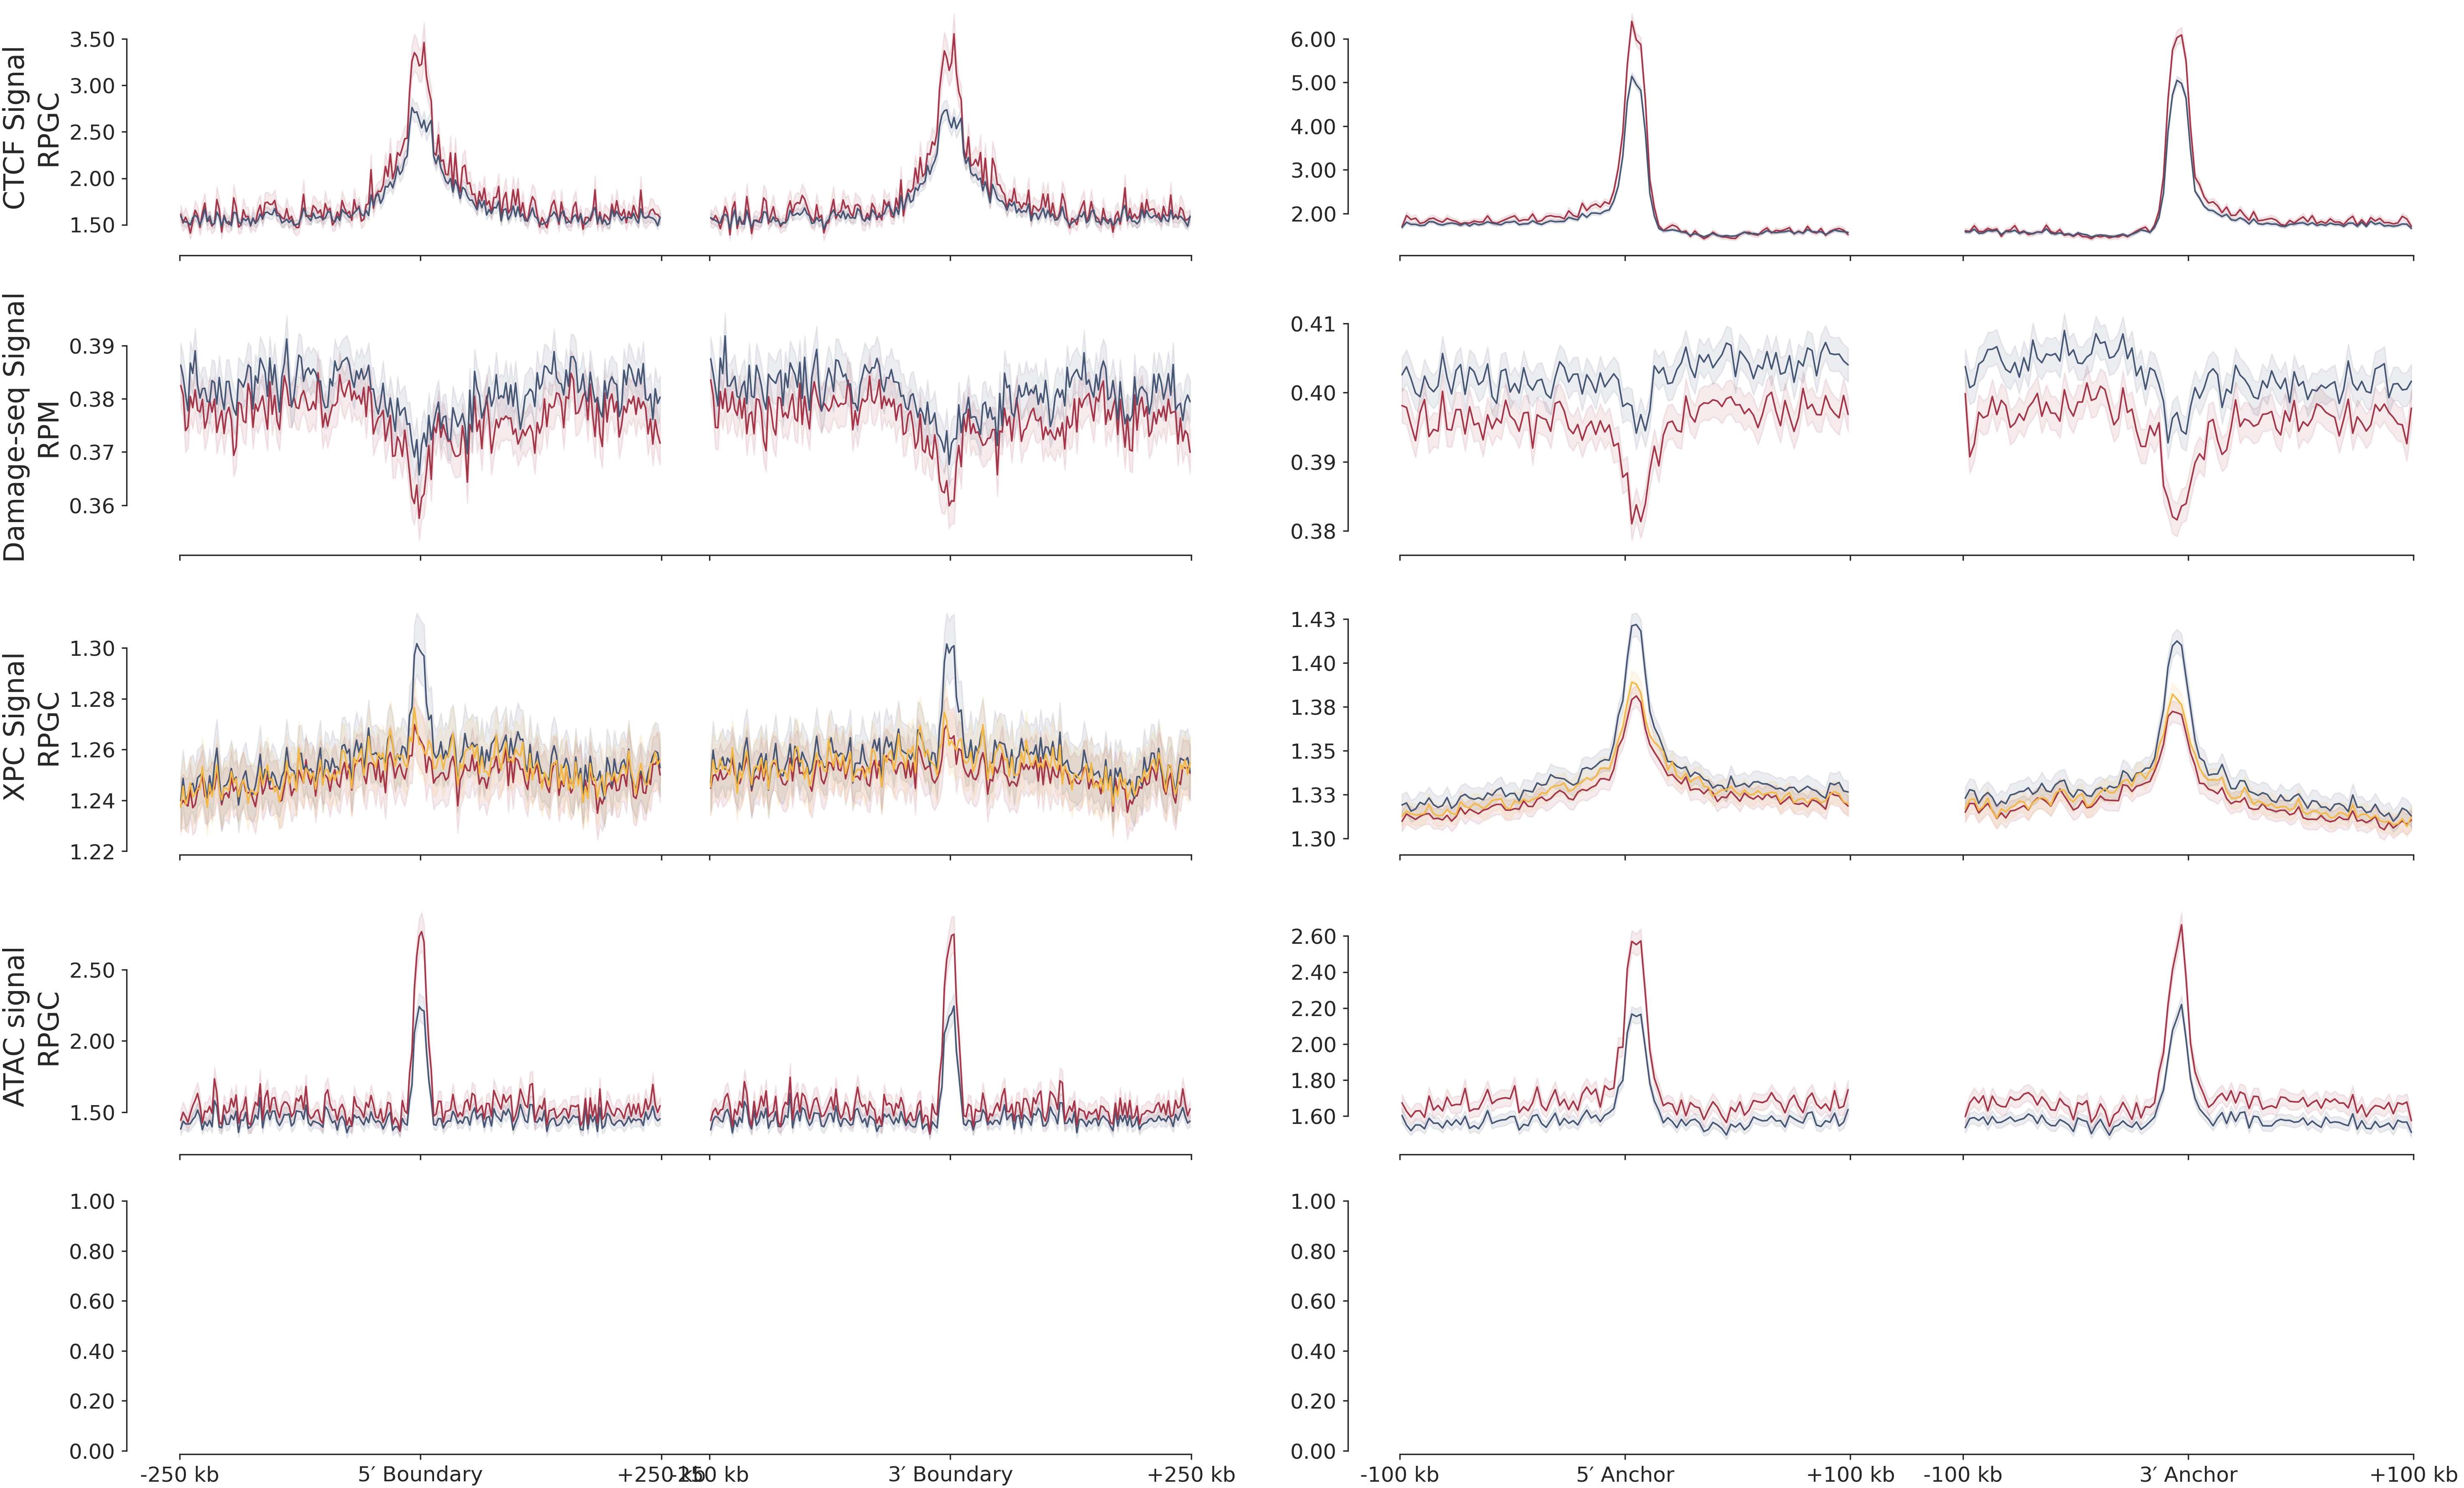

In [23]:
fig, axs = plt.subplots(5, 2, figsize=(24, 15), gridspec_kw={'wspace':0.1}, sharex='col')

# -----------------------
# Window / bin parameters
# -----------------------
tad_flank = 250_000
loop_flank = 100_000

tad_nbins  = 200
loop_nbins = 100
print(f"TAD nbins: {tad_nbins}, Loop nbins: {loop_nbins}")

tad_gap_bp  = 50_000
loop_gap_bp = 50_000 # *_gap_bp is the region not visualized in the center of the stackup. just technical thing to viz in the same axis.
summary_per_bin = 'mean'
znorm = None

# -----------------------
# Colors
# -----------------------
c_3h = plotting.COLORS[1]
c_1h = plotting.COLORS[2]
c_nouv = plotting.COLORS[0]
c_single_line = plotting.COLORS[0]

# -----------------------
# Common plotting kwargs
# -----------------------
COMMON_STACKUP_KW = dict(
    agg_across_regions="mean",
    shade="sem",
    color_alpha=0.05,
    vline_alpha=0,
    lw=0.9,
    shade_alpha=0.10,
    summary_per_bin=summary_per_bin
)

# Panel-type presets (TAD boundary vs loop anchor)
TAD_PRESET = dict(
    flank_bp=tad_flank,
    bins=tad_nbins,
    site_type="Boundary",
    gap_bp=tad_gap_bp,
    boundary_mode="concat",
)

LOOP_PRESET = dict(
    flank_bp=loop_flank,
    bins=loop_nbins,
    site_type="Anchor",
    gap_bp=loop_gap_bp,
    boundary_mode="concat",
)

# Assay-specific presets (znorm differs)
CTCF_PRESET = dict(znorm=znorm)
DS_PRESET   = dict(znorm=znorm)
XPC_PRESET = dict(znorm=znorm)
ATAC_PRESET = dict(znorm=znorm)

# axis titles
y_axis_titles = [
    "CTCF Signal\nRPGC",
    "Damage-seq Signal\nRPM",
    "XPC Signal\nRPGC",
    "ATAC signal\nRPGC",
]

# Convenience helper so calls stay short
def stackup(ax, regions, signal, palette, preset, assay):
    plot_flanks_start_end_stackup(
        regions, signal,
        ax=ax,
        palette=palette,
        **COMMON_STACKUP_KW,
        **preset,
        **assay,
    )

######
# CTCF - RPGC signal
######
stackup(axs[0, 0], tads, ctcf_wt_dict["wt_3h_ctcf"],   [c_3h],   TAD_PRESET,  CTCF_PRESET)
stackup(axs[0, 1], loops_full_common,    ctcf_wt_dict["wt_3h_ctcf"],   [c_3h],   LOOP_PRESET, CTCF_PRESET)

stackup(axs[0, 0], tads, ctcf_wt_dict["wt_nouv_ctcf"], [c_nouv], TAD_PRESET,  CTCF_PRESET)
stackup(axs[0, 1], loops_full_common,    ctcf_wt_dict["wt_nouv_ctcf"], [c_nouv], LOOP_PRESET, CTCF_PRESET)

# #####
# Damage-seq RPM Signal
# #####
stackup(axs[1, 0], tads, ds_dict_obs["wt_3h_ds"],   [c_3h],   TAD_PRESET,  DS_PRESET)
stackup(axs[1, 1], loops_full_common,    ds_dict_obs["wt_3h_ds"],   [c_3h],   LOOP_PRESET, DS_PRESET)

stackup(axs[1, 0], tads, ds_dict_obs["wt_nouv_ds"], [c_nouv], TAD_PRESET,  DS_PRESET)
stackup(axs[1, 1], loops_full_common,    ds_dict_obs["wt_nouv_ds"], [c_nouv], LOOP_PRESET, DS_PRESET)

####
# XPC
# RPGC signal
####
stackup(axs[2, 0], tads, xpc_wt_dict["wt_3h_xpc"],   [c_3h],   TAD_PRESET,  XPC_PRESET)
stackup(axs[2, 1], loops_full_common,    xpc_wt_dict["wt_3h_xpc"],   [c_3h],   LOOP_PRESET, XPC_PRESET)

stackup(axs[2, 0], tads, xpc_wt_dict["wt_nouv_xpc"], [c_nouv], TAD_PRESET,  XPC_PRESET)
stackup(axs[2, 1], loops_full_common,    xpc_wt_dict["wt_nouv_xpc"], [c_nouv], LOOP_PRESET, XPC_PRESET)

stackup(axs[2, 0], tads, xpc_wt_dict["wt_1h_xpc"],   [c_1h],   TAD_PRESET,  XPC_PRESET)
stackup(axs[2, 1], loops_full_common,    xpc_wt_dict["wt_1h_xpc"],   [c_1h],   LOOP_PRESET, XPC_PRESET)

####
# ATAC-seq
####

stackup(axs[3, 0], tads, atac_wt_dict["wt_nouv_atac"], [c_nouv], TAD_PRESET, ATAC_PRESET)
stackup(axs[3, 1], loops_full_common,    atac_wt_dict["wt_nouv_atac"], [c_nouv], LOOP_PRESET, ATAC_PRESET)

stackup(axs[3, 0], tads, atac_wt_dict["wt_3h_atac"],   [c_3h],   TAD_PRESET, ATAC_PRESET)
stackup(axs[3, 1], loops_full_common,    atac_wt_dict["wt_3h_atac"],   [c_3h],   LOOP_PRESET, ATAC_PRESET)

for i in range(4):
    axs[i, 0].set_ylabel(y_axis_titles[i])
    axs[i, 1].set_ylabel("")
    axs[i, 0].set_title("")
    axs[i, 1].set_title("")

# --- Axis cosmetics ---
for ax in axs.flatten():
    plotting.despine(ax=ax)
    ax.set_xlabel("")
    # make x, y labels bigger
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    # remove legends
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    # make x and y ticks bigger
    ax.tick_params(axis='both', which='major', labelsize=12)

    # make y ticks 2 digits after comma
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig2_rework2/stackups_tads_loops_separated.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig2_rework2/stackups_tads_loops_separated.svg', dpi=300, bbox_inches='tight')

<Axes: >

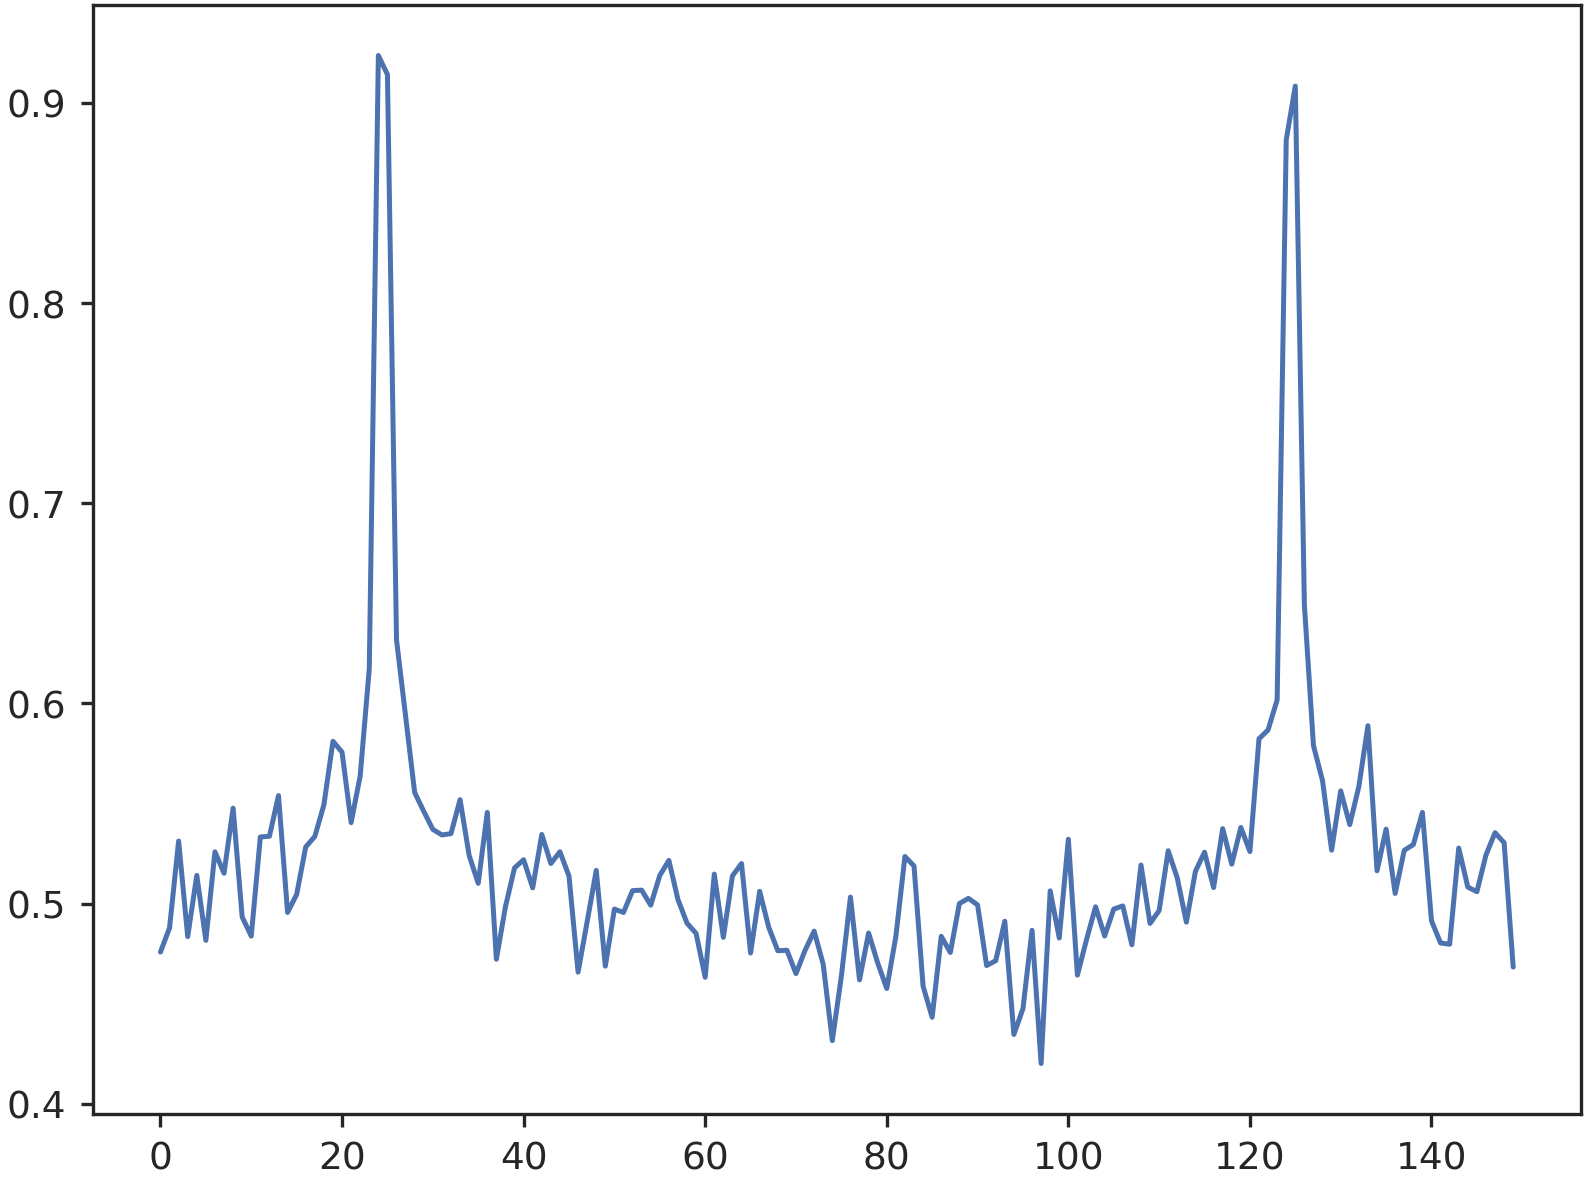

In [16]:
promoter_bw = {'promoter': ['/home/carlos/Clone/ggner-3d/misc/promoter_density_1kb_window_500bp_flank.bw']}

promoter_stackup_tads_q = stackup_bw_dict(promoter_bw, tads)

sns.lineplot(np.nansum(promoter_stackup_tads_q['promoter'], axis=0))

### damageseq only

In [17]:
from ggner_3d.plotting import plot_flanks_start_end_stackup

znorm='region'
boundary_mode='concat'

/home/carlos/Clone/ggner-3d/src/ggner_3d/plotting.py:683: RuntimeWarning: Mean of empty slice
  em = np.nanmean(np.stack(em, axis=0), axis=0)
/home/carlos/Clone/ggner-3d/src/ggner_3d/plotting.py:683: RuntimeWarning: Mean of empty slice
  em = np.nanmean(np.stack(em, axis=0), axis=0)
/home/carlos/Clone/ggner-3d/src/ggner_3d/plotting.py:683: RuntimeWarning: Mean of empty slice
  em = np.nanmean(np.stack(em, axis=0), axis=0)
/home/carlos/Clone/ggner-3d/src/ggner_3d/plotting.py:683: RuntimeWarning: Mean of empty slice
  em = np.nanmean(np.stack(em, axis=0), axis=0)
/home/carlos/Clone/ggner-3d/src/ggner_3d/plotting.py:683: RuntimeWarning: Mean of empty slice
  em = np.nanmean(np.stack(em, axis=0), axis=0)
/home/carlos/Clone/ggner-3d/src/ggner_3d/plotting.py:683: RuntimeWarning: Mean of empty slice
  em = np.nanmean(np.stack(em, axis=0), axis=0)
/home/carlos/Clone/ggner-3d/src/ggner_3d/plotting.py:683: RuntimeWarning: Mean of empty slice
  em = np.nanmean(np.stack(em, axis=0), axis=0)
/home/

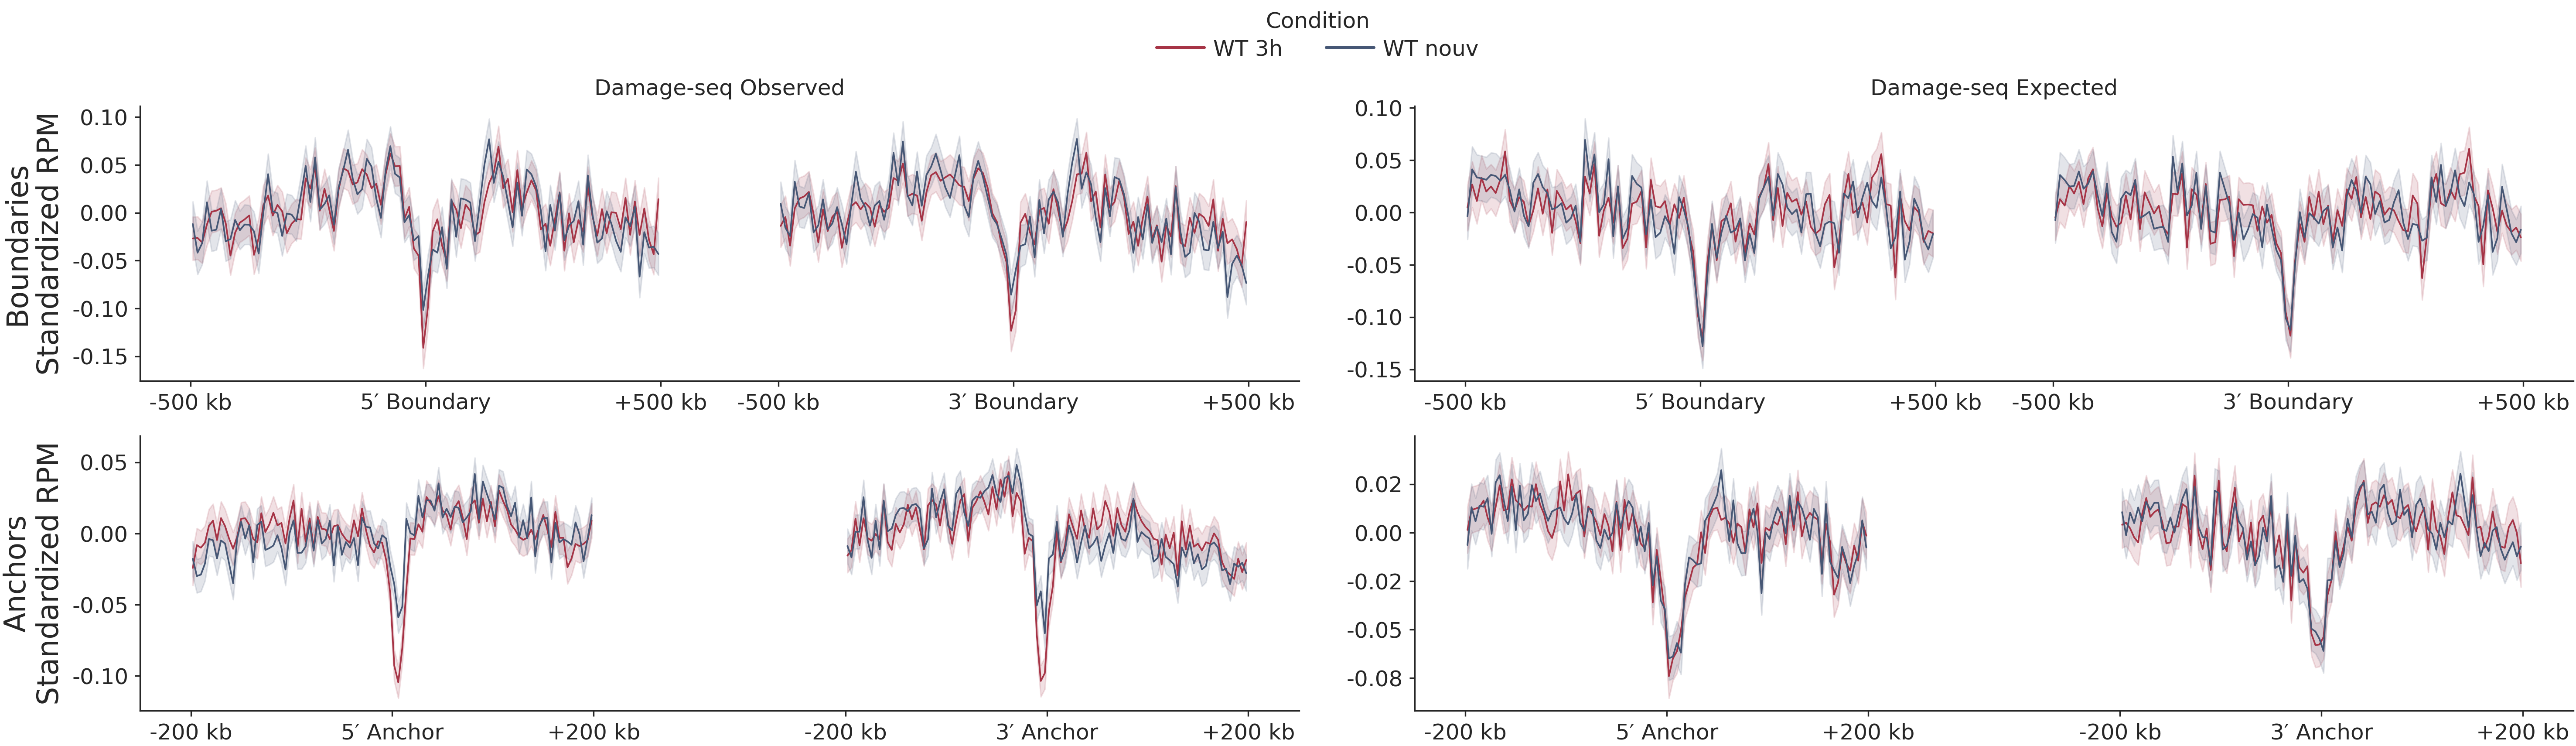

In [20]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Figure / axes ---
fig, axs = plt.subplots(2, 2, figsize=(24, 6), gridspec_kw={'wspace':0.1}, sharex='row')

plotting.update_rcparams()

# --- Colors / legend handles (proxy legend; works even if your plotting function returns nothing) ---
c_3h = plotting.COLORS[1]
c_nouv = plotting.COLORS[0]

legend_handles = [
    Line2D([0], [0], color=c_3h, lw=1.5, label="WT 3h"),
    Line2D([0], [0], color=c_nouv, lw=1.5, label="WT nouv"),
]

# --- TADs: Observed (top-left) ---
plot_flanks_start_end_stackup(
    tads, ds_dict_obs["wt_3h_ds"],
    flank_bp=500_000, bins=100, palette=[c_3h],
    boundary_mode=boundary_mode, agg_across_regions="mean",
    ax=axs[0, 0], shade="sem", znorm=znorm,
    color_alpha=0.1, vline_alpha=0, lw=0.9,
    shade_alpha=0.15, site_type="Boundary"
)
plot_flanks_start_end_stackup(
    tads, ds_dict_obs["wt_nouv_ds"],
    flank_bp=500_000, bins=100, palette=[c_nouv],
    boundary_mode=boundary_mode, agg_across_regions="mean",
    ax=axs[0, 0], shade="sem", znorm=znorm,
    color_alpha=0.1, vline_alpha=0, lw=0.9,
    shade_alpha=0.15, site_type="Boundary"
)

# --- TADs: Expected (top-right) ---
plot_flanks_start_end_stackup(
    tads, ds_dict_exp["wt_3h_ds"],
    flank_bp=500_000, bins=100, palette=[c_3h],
    boundary_mode=boundary_mode, agg_across_regions="mean",
    ax=axs[0, 1], shade="sem", znorm=znorm,
    color_alpha=0.1, vline_alpha=0, lw=0.9,
    shade_alpha=0.15, site_type="Boundary"
)
plot_flanks_start_end_stackup(
    tads, ds_dict_exp["wt_nouv_ds"],
    flank_bp=500_000, bins=100, palette=[c_nouv],
    boundary_mode=boundary_mode, agg_across_regions="mean",
    ax=axs[0, 1], shade="sem", znorm=znorm,
    color_alpha=0.1, vline_alpha=0, lw=0.9,
    shade_alpha=0.15, site_type="Boundary"
)

# --- Loops: Observed (bottom-left) ---
plot_flanks_start_end_stackup(
    loops_full_common, ds_dict_obs["wt_3h_ds"],
    flank_bp=200_000, bins=100, palette=[c_3h],
    boundary_mode=boundary_mode, agg_across_regions="mean",
    ax=axs[1, 0], shade="sem", znorm=znorm,
    color_alpha=0.1, vline_alpha=0, lw=0.9,
    shade_alpha=0.15, site_type="Anchor"
)
plot_flanks_start_end_stackup(
    loops_full_common, ds_dict_obs["wt_nouv_ds"],
    flank_bp=200_000, bins=100, palette=[c_nouv],
    boundary_mode=boundary_mode, agg_across_regions="mean",
    ax=axs[1, 0], shade="sem", znorm=znorm,
    color_alpha=0.1, vline_alpha=0, lw=0.9,
    shade_alpha=0.15, site_type="Anchor"
)

# --- Loops: Expected (bottom-right) ---
plot_flanks_start_end_stackup(
    loops_full_common, ds_dict_exp["wt_3h_ds"],
    flank_bp=200_000, bins=100, palette=[c_3h],
    boundary_mode=boundary_mode, agg_across_regions="mean",
    ax=axs[1, 1], shade="sem", znorm=znorm,
    color_alpha=0.1, vline_alpha=0, lw=0.9,
    shade_alpha=0.15, site_type="Anchor"
)
plot_flanks_start_end_stackup(
    loops_full_common, ds_dict_exp["wt_nouv_ds"],
    flank_bp=200_000, bins=100, palette=[c_nouv],
    boundary_mode=boundary_mode, agg_across_regions="mean",
    ax=axs[1, 1], shade="sem", znorm=znorm,
    color_alpha=0.1, vline_alpha=0, lw=0.9,
    shade_alpha=0.15, site_type="Anchor"
)

# --- Titles / labels ---
axs[0, 0].set_title("Damage-seq Observed")
axs[0, 1].set_title("Damage-seq Expected")
axs[1, 0].set_title("")
axs[1, 1].set_title("")

axs[0, 0].set_ylabel("Boundaries\nStandardized RPM")
axs[1, 0].set_ylabel("Anchors\nStandardized RPM")
axs[0, 1].set_ylabel("")
axs[1, 1].set_ylabel("")

n_tads = len(tads)
n_loops = len(loops_full_common)

# --- Axis cosmetics ---
for ax in axs.flatten():
    # plotting.despine(ax=ax)
    ax.set_xlabel("")
    # make x, y labels bigger
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    # remove legends
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    # make x and y ticks bigger
    ax.tick_params(axis='both', which='major', labelsize=12)

    # make y ticks 2 digits after comma
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

# --- One legend for the whole figure ---
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    title="Condition",
    bbox_to_anchor=(0.5, 1.02),
    fontsize=12,
    title_fontsize=12
)

# # --- Save ---
fig.savefig(
    "/home/carlos/Clone/ggner-3d/figs/fig2_rework2/ds_observed_expected_stackups.svg",
)